The time-independent Schrödinger equation for a periodic infinite array of attractive delta potentials (a Dirac comb) is:

$$
    -\frac{\hbar^2}{2m}\frac{d^2\psi(x)}{dx^2} - \alpha \sum_{n=-\infty}^{\infty} \delta(x - n a)\,\psi(x) = E\,\psi(x),
$$

where:
- $\hbar$ is the reduced Planck constant,
- $m$ is the particle mass,
- $\alpha > 0$ is the strength of each attractive delta potential,
- $a$ is the lattice spacing (period),
- $E$ is the energy eigenvalue (we assume $E < 0$),
- $\psi(x)$ is the wave function.

Introducing dimensionless variables:

$x' = x / a$ $\quad$ $x' \in [0, 1]$, \
$g = (2 m \alpha a) / \hbar ^ 2$ $\quad$ $g > 0$, \
$\varepsilon = (2 m a ^ 2 E) / \hbar ^ 2$ $\quad$ $\varepsilon < 0$, \
$\psi'(x') = \sqrt{a} \, \psi(a x')$.

We rewrite the differential equation:

$$
    -\frac{d^2\psi'(x')}{dx'^2} - g \sum_{n=-\infty}^{\infty} \delta(x'-n)\,\psi'(x') = \varepsilon\,\psi'(x')
$$

Applying Bloch's theorem in dimensionless form:

$$
    \psi'(x') = e^{i k' x'} u'(x'), \quad k' \in [- \pi, \pi]
$$

We obtain:

$$
    -\frac{d^2 u'}{dx'^2} - 2i k' \frac{d u'}{dx'} + \bigl(k'^2 - \varepsilon\bigr) u' = 0
$$

The delta potentials at the cell boundaries are incorporated through the following boundary conditions, derived from the continuity of $\psi'$ and the derivative jump condition $\psi_x'(0^+) - \psi_x'(0^-) = -g\,\psi'(0)$ combined with the Bloch periodicity:

$$
    u'(1) = u'(0), \qquad \frac{du'}{dx'}(1) = \frac{du'}{dx'}(0) + g\, u'(0)
$$

We're going to solve analytically the equation to find the band structure $\varepsilon (k)$.

```maxima
(%i4)	/* Declare variables*/
(%o1)	done

(%o2)	done

(%o3)	done

(%o4)	[x>0,x<1,E<0,k>=-%pi,k<=%pi]
(%i5)	/* Solve the differential equation*/
	sol: desolve(- diff(u(x), x, 2) - 2 * %i * k * diff(u(x), x, 1) + (k ^ 2 - E) * u(x) = 0, u(x));
(sol)	u(x)=%e^(-(%i*k*x))*((sinh(sqrt(-E)*x)*(2*(at('diff(u(x),x),x=0)+2*%i*u(0)*k)-2*%i*u(0)*k))/(2*sqrt(-E))+
u(0)*cosh(sqrt(-E)*x))
(%i6)	/* Rewrite conditions with C_1 and C_2*/
	sol: rhs(subst([
	            at(diff(u(x), x, 1), x = 0) = C_2,
	            at(u(x), x = 0) = C_1], sol));
(sol)	%e^(-(%i*k*x))*(((2*(2*%i*C_1*k+C_2)-2*%i*C_1*k)*sinh(sqrt(-E)*x))/(2*sqrt(-E))+C_1*cosh(sqrt(-E)*x))
```

The general solution for $x' \in (0, 1)$ is:

$$
	u(x) = e^{-i k x} \left( C_1 \cosh\!\left(\sqrt{-E}\,x\right) + \frac{C_2 + i k C_1}{\sqrt{-E}} \sinh\!\left(\sqrt{-E}\,x\right) \right)
$$

Applying conditions:

```maxima
(%i7)	/* Periodic condition*/
	eq1: factor(at(sol, x = 0) = at(sol, x = 1));
(eq1)	C_1=(%e^(-(%i*k))*(%i*C_1*sinh(sqrt(-E))*k+C_1*cosh(sqrt(-E))*sqrt(-E)+C_2*sinh(sqrt(-E))))/sqrt(-E)
(%i9)	declare(g, real);
	assume(g > 0);
(%o8)	done

(%o9)	[g>0]
(%i10)	/* Delta jump condition*/
	eq2: factor(at(diff(sol, x, 1), x = 1) = at(diff(sol, x, 1), x = 0) + g * at(sol, x = 0));
(eq2)	(%e^(-(%i*k))*(C_1*sinh(sqrt(-E))*k^2-%i*C_2*sinh(sqrt(-E))*k-C_1*sinh(sqrt(-E))*E+C_2*
cosh(sqrt(-E))*sqrt(-E)))/sqrt(-E)=C_1*g+C_2
```

We have these two equations:

\begin{cases}
	C_1\sqrt{-E} = e^{-ik}\Bigl[i k C_1 \sinh\!\bigl(\sqrt{-E}\bigr) + C_1\sqrt{-E}\cosh\!\bigl(\sqrt{-E}\bigr) + C_2\sinh\!\bigl(\sqrt{-E}\bigr)\Bigr] \\
	e^{-ik}\;\frac{C_1 k^2 \sinh\!\bigl(\sqrt{-E}\bigr) - i k C_2\sinh\!\bigl(\sqrt{-E}\bigr) - C_1 E\sinh\!\bigl(\sqrt{-E}\bigr) + C_2\sqrt{-E}\cosh\!\bigl(\sqrt{-E}\bigr)}{\sqrt{-E}} = C_1 g + C_2
\end{cases}

Let's find the coefficient matrix form:

```maxima
(%i11)	/* Matrix form*/
	A: coefmatrix([eq1, eq2], [C_1, C_2]);
(A)	matrix(
		[-((%e^(-(%i*k))*(%i*sinh(sqrt(-E))*k+(cosh(sqrt(-E))-%e^(%i*k))*sqrt(-E)))/sqrt(-E)),	-((%e^(-(%i*k))*sinh(sqrt(-E)))/sqrt(-E))],
		[(%e^(-(%i*k))*(sinh(sqrt(-E))*k^2-%e^(%i*k)*sqrt(-E)*g-sinh(sqrt(-E))*E))/sqrt(-E),	-((%e^(-(%i*k))*(%i*sinh(sqrt(-E))*k+(%e^(%i*k)-cosh(sqrt(-E)))*sqrt(-E)))/sqrt(-E))]
	)
```

$$
	\begin{pmatrix}
		-\dfrac{e^{-ik}\Bigl(i k \sinh(\sqrt{-E}) + \sqrt{-E}\bigl(\cosh(\sqrt{-E}) - e^{ik}\bigr)\Bigr)}{\sqrt{-E}} & 
		-\dfrac{e^{-ik}\sinh(\sqrt{-E})}{\sqrt{-E}} \\[10pt]
		\dfrac{e^{-ik}\Bigl(k^2 \sinh(\sqrt{-E}) - e^{ik}\sqrt{-E}\,g - E\sinh(\sqrt{-E})\Bigr)}{\sqrt{-E}} & 
		-\dfrac{e^{-ik}\Bigl(i k \sinh(\sqrt{-E}) + \sqrt{-E}\bigl(e^{ik} - \cosh(\sqrt{-E})\bigr)\Bigr)}{\sqrt{-E}}
	\end{pmatrix}
$$

To find a physical solution, A's determinant must be zero. This will lead to the band structure equation:

```maxima
(%i12)	/* Determinant of A*/
	d: trigsimp(determinant(A));
(d)	(%e^(-(2*%i*k))*(%e^(%i*k)*sinh(sqrt(-E))*sqrt(-E)*g+(2*%e^(%i*k)*cosh(sqrt(-E))-%e^(2*%i*k)-1)*E))/E
(%i14)	declare(s, real);
	assume(s > 0);
(%o13)	done

(%o14)	[s>0]
(%i15)	/* Let varepsilon = - s ^ 2*/
	d: subst(E = - s ^ 2, d);
(d)	-((%e^(-(2*%i*k))*(%e^(%i*k)*g*s*sinh(s)-s^2*(2*%e^(%i*k)*cosh(s)-%e^(2*%i*k)-1)))/s^2)
(%i16)	/* Band structure*/
	solve(d = 0, cosh(s));
(%o16)	[cosh(s)=(%e^(-(%i*k))*(%e^(%i*k)*g*sinh(s)+(%e^(2*%i*k)+1)*s))/(2*s)]
```

Solution:

$$
	\boxed{\cosh(s) = \cos(k) + \frac{g}{2s}\,\sinh(s)}
$$

Where $s = - \varepsilon ^ 2$. Let's solve it

In [1]:
# Importing libraries
import numpy as np
from scipy.optimize import brentq
import matplotlib.pyplot as plt
plt.style.use('grayscale')

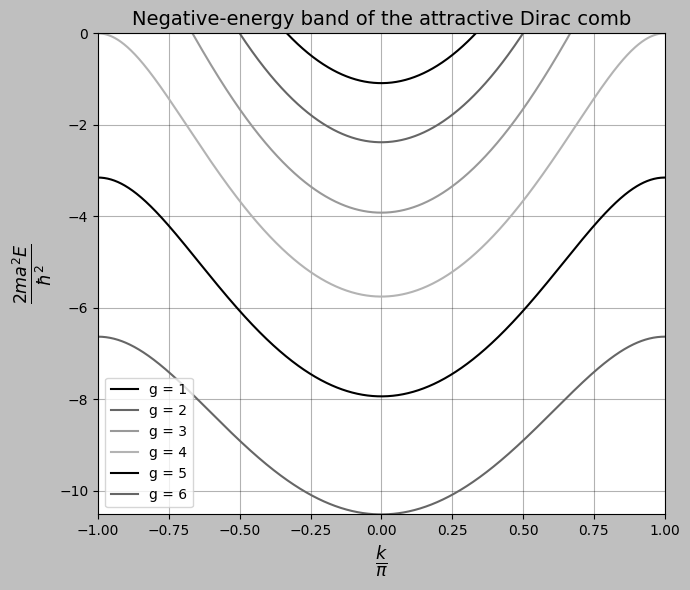

In [2]:
g_vals = [1, 2, 3, 4, 5, 6] # g set
k_vals = np.linspace(- np.pi, np.pi, 1_000) # Bloch wave-numbers

plt.figure(figsize = (7, 6))

for g in g_vals:
    epsilon = []  # dimensionless energy values for this g

    for k in k_vals:
        # Equation: cosh(s) - g/(2s) sinh(s) = cos(k)
        target = np.cos(k)

        F0 = 1.0 - g / 2.0 # Function at s -> 0 (limit)

        if target < F0: # No negative-energy state for this k
            epsilon.append(np.nan)
            continue

        s_low = 1e-12 # Lower bound near zero (avoid exact zero)
        F_low = np.cosh(s_low) - (g / (2 * s_low)) * np.sinh(s_low)

        s_high = 1.0 # Upper bound (increase until F(s) >= target)

        while True:
            F_high = np.cosh(s_high) - (g / (2 * s_high)) * np.sinh(s_high)
            if F_high >= target:
                break
            s_high *= 1.1

        try: # Solve for s_root
            s_root = brentq(lambda s: np.cosh(s) - (g / (2 * s)) * np.sinh(s) - target, s_low, s_high)
            epsilon.append(-s_root**2)
        except ValueError:
            epsilon.append(np.nan)

    epsilon = np.array(epsilon)
    plt.plot(k_vals / np.pi, epsilon, label=f'g = {g}') # Plotting

plt.xlabel(r'$\frac{k}{\pi}$', fontsize = 18)
plt.ylabel(r'$\frac{2 m a ^{2} E}{\hbar ^{2}}$', fontsize = 18)
plt.title('Negative‑energy band of the attractive Dirac comb', fontsize = 14)
plt.xlim(-1, 1)
plt.ylim(min(epsilon), 0)
plt.legend()
plt.grid(True, alpha = 0.3)
plt.tight_layout()
plt.show()